In [33]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2
    
import os
import sys

# add parent directory to sys.path to import STL package modules
PARENT_DIR = os.path.dirname(os.path.abspath(os.getcwd() + "/../regrid_to_healpix"))
sys.path.append(PARENT_DIR)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
import healpix_geo 
import numpy as np
from foscat.Plot import lgnomproject
import matplotlib.pyplot as plt

level=14
ilevel=14
ndata=128
cell_ids=3*4**ilevel+np.arange(ndata*ndata)
lon,lat = healpix_geo.nested.healpix_to_lonlat(cell_ids, ilevel,ellipsoid='WGS84')
val=lon

In [44]:
from regrid_to_healpix.regrid_to_healpix_bilinear import Set

nr = Set(lon_deg=lon, lat_deg=lat, level=level)  # Npt=1 imposé dans nearest
# puis:
hval     = nr.transform(val,lam=0.1)  # selon ton API
rval     = nr.invert(hval)
cell_ids = nr.get_cell_ids()
hval.shape,rval.shape

((16896,), (16384,))

np.float64(2.89495102025858e-13)

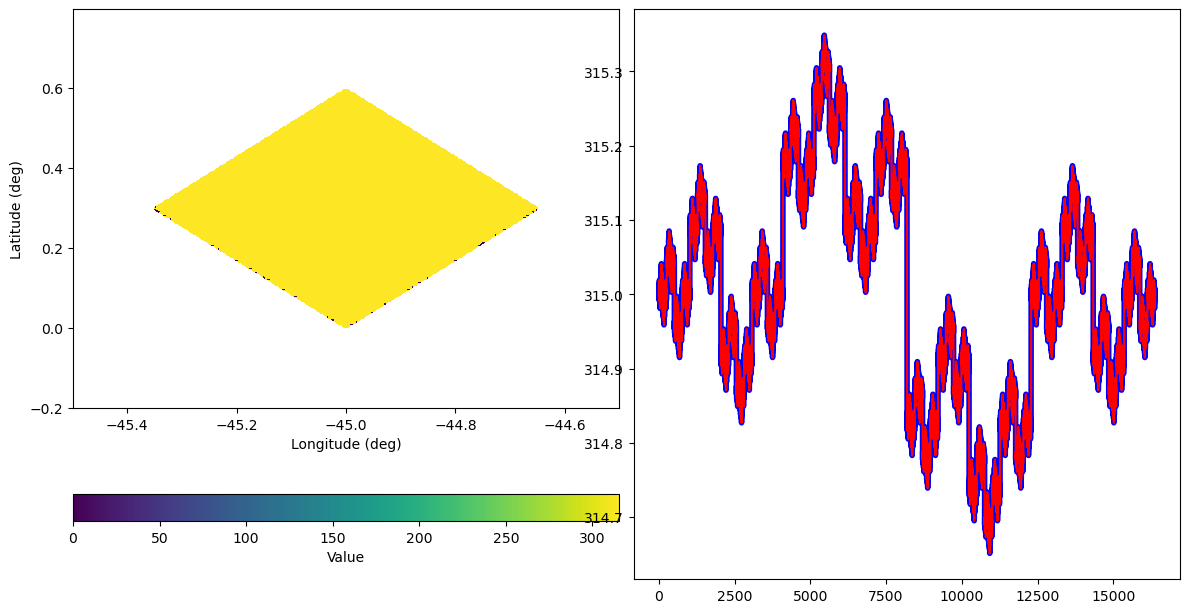

In [45]:
plt.figure(figsize=(12,6))
lgnomproject(cell_ids,hval,2**(level),hold=False,fov_deg=1,interp=False,sub=(1,2,1),cbar=True)
plt.subplot(1,2,2)
plt.plot(lon,color='b',lw=4)
plt.plot(rval,color='r')
np.mean((rval-lon)**2)

In [19]:
from regrid_to_healpix.regrid_to_healpix_psf import Set

nr = Set(lon_deg=lon, lat_deg=lat, level=level)  # Npt=1 imposé dans nearest
# puis:
hval     = nr.transform(val,lam=0.1)  # selon ton API
rval     = nr.invert(hval)
cell_ids = nr.get_cell_ids()
hval.shape,rval.shape

Itt 0 : 1.893e-05
Itt 4 : 7.842e-07
Itt 8 : 1.019e-07
Itt 12 : 2.062e-08
Itt 16 : 3.59e-09
Itt 20 : 1.267e-09
Itt 24 : 1.768e-09
Itt 28 : 9.497e-10
Itt 32 : 1.127e-09
Itt 36 : 7.189e-10
Itt 40 : 3.423e-10
Itt 44 : 1.487e-10
Itt 48 : 7.851e-11
Itt 52 : 5.151e-11
Itt 56 : 4.55e-11
Itt 60 : 2.303e-11
Itt 64 : 1.361e-11
Itt 68 : 7.743e-12
Itt 72 : 5.047e-12
Itt 76 : 4.28e-12
Itt 80 : 6.057e-12
Itt 84 : 4.182e-12
Itt 88 : 2.956e-12
Itt 92 : 3.381e-12
Itt 96 : 3.232e-12
Final Itt 99 : 2.45e-12


((4354,), (16384,))

np.float64(2.60931990477316e-08)

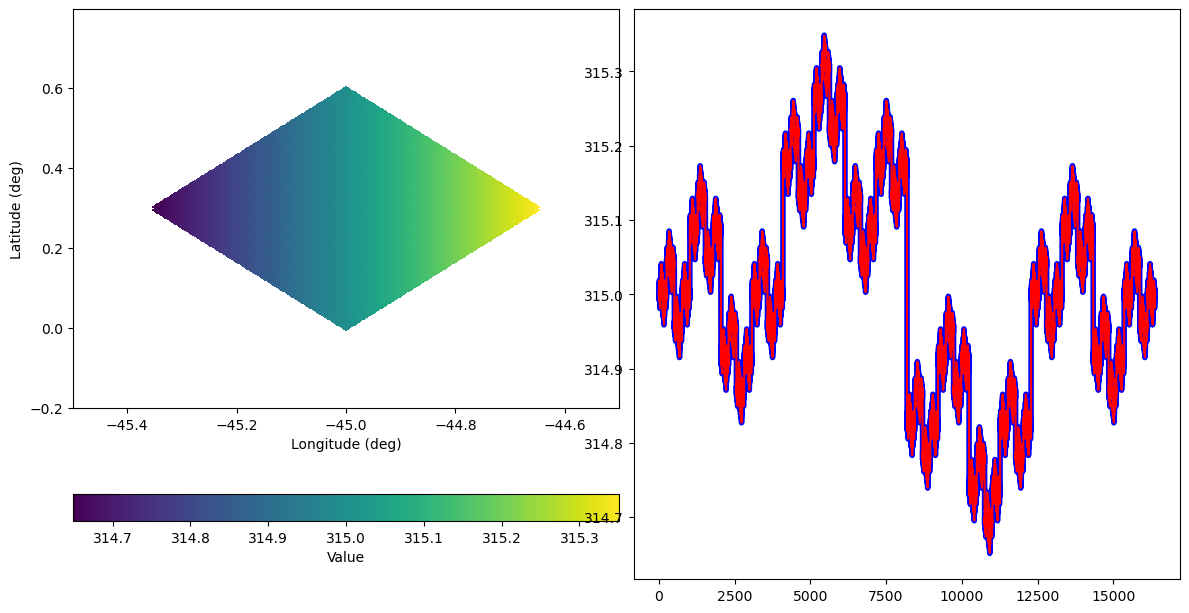

In [15]:
plt.figure(figsize=(12,6))
lgnomproject(cell_ids,hval,2**(level),hold=False,fov_deg=1,interp=False,sub=(1,2,1),cbar=True)
plt.subplot(1,2,2)
plt.plot(lon,color='b',lw=4)
plt.plot(rval,color='r')
np.mean((rval-lon)**2)

In [20]:
from regrid_to_healpix.regrid_to_healpix_nearest import Set

nr = Set(lon_deg=lon, lat_deg=lat, level=level)  # Npt=1 imposé dans nearest
# puis:
hval     = nr.transform(val)  # selon ton API
rval     = nr.invert(hval)
cell_ids = nr.get_cell_ids()
hval.shape,rval.shape

((4096,), (16384,))

np.float64(3.771856427192688e-06)

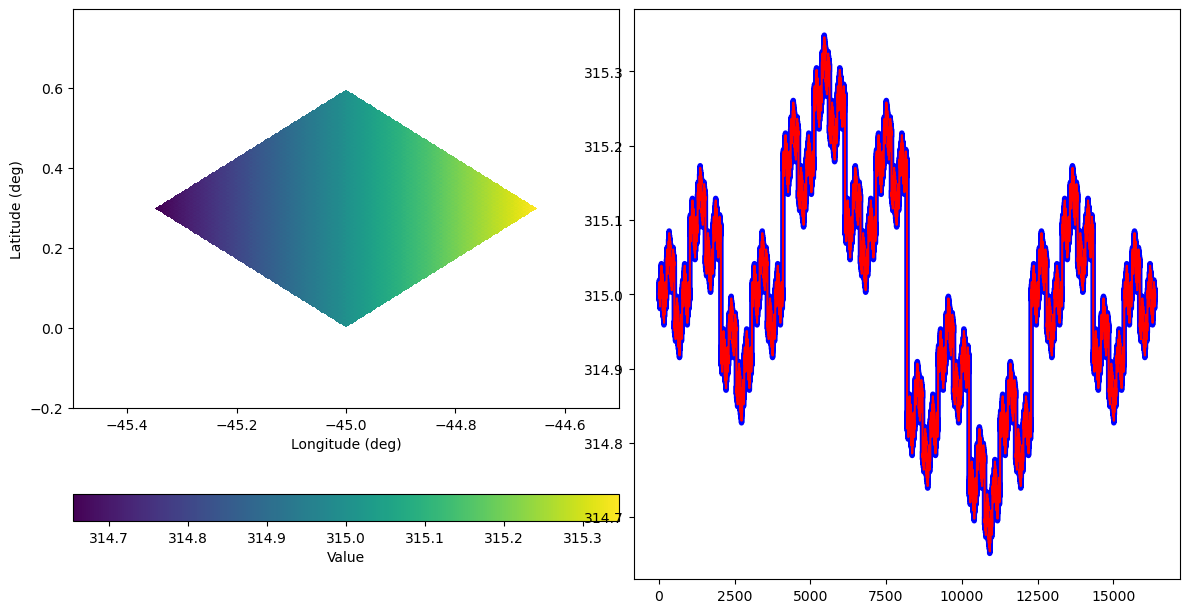

In [21]:

plt.figure(figsize=(12,6))
lgnomproject(cell_ids,hval,2**(level),hold=False,fov_deg=1,interp=False,sub=(1,2,1),cbar=True)
plt.subplot(1,2,2)
plt.plot(lon,color='b',lw=4)
plt.plot(rval,color='r')
np.mean((rval-lon)**2)